In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import os

os.environ["OMP_NUM_THREADS"] = "1"

https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/

https://www.naftaliharris.com/blog/visualizing-k-means-clustering/


In [4]:
dataset = pd.read_csv("data/Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
# sns.pairplot(dataset.iloc[:, [2, 3, 4]])

## Part One: KMeans Clustering


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch

In [7]:
X = dataset.iloc[:, [3, 4]].values
sc_X = StandardScaler()
X = sc_X.fit_transform(X)
X.shape, X

((200, 2),
 array([[-1.73899919, -0.43480148],
        [-1.73899919,  1.19570407],
        [-1.70082976, -1.71591298],
        [-1.70082976,  1.04041783],
        [-1.66266033, -0.39597992],
        [-1.66266033,  1.00159627],
        [-1.62449091, -1.71591298],
        [-1.62449091,  1.70038436],
        [-1.58632148, -1.83237767],
        [-1.58632148,  0.84631002],
        [-1.58632148, -1.4053405 ],
        [-1.58632148,  1.89449216],
        [-1.54815205, -1.36651894],
        [-1.54815205,  1.04041783],
        [-1.54815205, -1.44416206],
        [-1.54815205,  1.11806095],
        [-1.50998262, -0.59008772],
        [-1.50998262,  0.61338066],
        [-1.43364376, -0.82301709],
        [-1.43364376,  1.8556706 ],
        [-1.39547433, -0.59008772],
        [-1.39547433,  0.88513158],
        [-1.3573049 , -1.75473454],
        [-1.3573049 ,  0.88513158],
        [-1.24279661, -1.4053405 ],
        [-1.24279661,  1.23452563],
        [-1.24279661, -0.7065524 ],
        [-1.24279

In [8]:
def plot_k_means_elbow(X, start_index=1, num_points=10):
    wcss = []
    stop_index = start_index + num_points

    for i in range(start_index, stop_index):
        kmeans = KMeans(n_init="auto", n_clusters=i, init="k-means++", random_state=42)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)

    plt.plot(range(start_index, stop_index), wcss)
    plt.title("The Elbow Method")
    plt.xlabel("Number of clusters")
    plt.ylabel("WCSS")
    plt.show()


def get_blue_spectrum(num_clusters):
    from matplotlib import colormaps

    blues = colormaps["Blues"].resampled(num_clusters + 2)
    colors = [blues(i) for i in range(2, num_clusters + 2)]
    return colors


def plot_clusters(
    X,
    y_values,
    colors=None,
    point_size=100,
    num_clusters=1,
    centroids=None,
    centroid_color="black",
    centroid_label="Centroids",
    title="Clusters",
    x_label="X - Axis",
    y_label="Y - Axis",
    plot_noise=False,
    noise_color="magenta",
):
    import numpy as np
    import matplotlib.pyplot as plt

    print("y_values", y_values.shape)
    print("X", X.shape)

    if colors is None:
        colors = get_blue_spectrum(num_clusters)
    elif num_clusters > len(colors):
        print(
            f"""
            Number of clusters ({num_clusters}) is greater than the number of colors ({len(colors)}).
            Extending with blue spectrum.
            """
        )
        colors = (
            colors + get_blue_spectrum(num_clusters)[0 : num_clusters - len(colors)]
        )

    plt.figure(figsize=(8, 8))
    for j in range(num_clusters):
        mask = y_values == j
        # we will only plot cluster points if they exist
        if np.any(mask):
            x_axis = X[mask, 0]
            y_axis = X[mask, 1]
            plt.scatter(
                x_axis, y_axis, s=point_size, c=colors[j], label=f"Cluster {j+1}"
            )

    if plot_noise:
        noise_mask = y_values == -1
        plt.scatter(
            X[noise_mask, 0],
            X[noise_mask, 1],
            s=point_size,
            c=noise_color,
            label="Noise",
        )

    if centroids is not None and centroids.any():
        print("centroids", centroids.shape)
        plt.scatter(
            centroids[:, 0],
            centroids[:, 1],
            s=2 * point_size,
            c=centroid_color,
            label=centroid_label,
        )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.show()

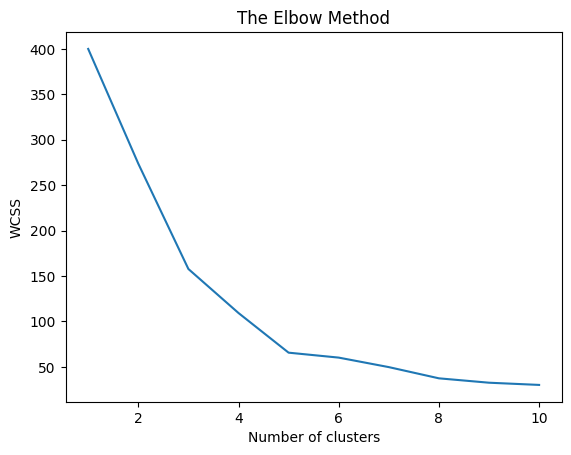

In [9]:
plot_k_means_elbow(X)

In [10]:
num_clusters = 5  # inferred from elbow chart
kmeans = KMeans(
    n_init="auto", n_clusters=num_clusters, init="k-means++", random_state=42
)
y_kmeans = kmeans.fit_predict(X)
y_kmeans.shape, y_kmeans
# y_kmeans.shape, kmeans.cluster_centers_, kmeans.cluster_centers_.shape, kmeans.__dict__, y_kmeans

((200,),
 array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
        4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
        4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
        0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
        3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
        3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
        3, 1], dtype=int32))

y_values (200,)
X (200, 2)
centroids (5, 2)


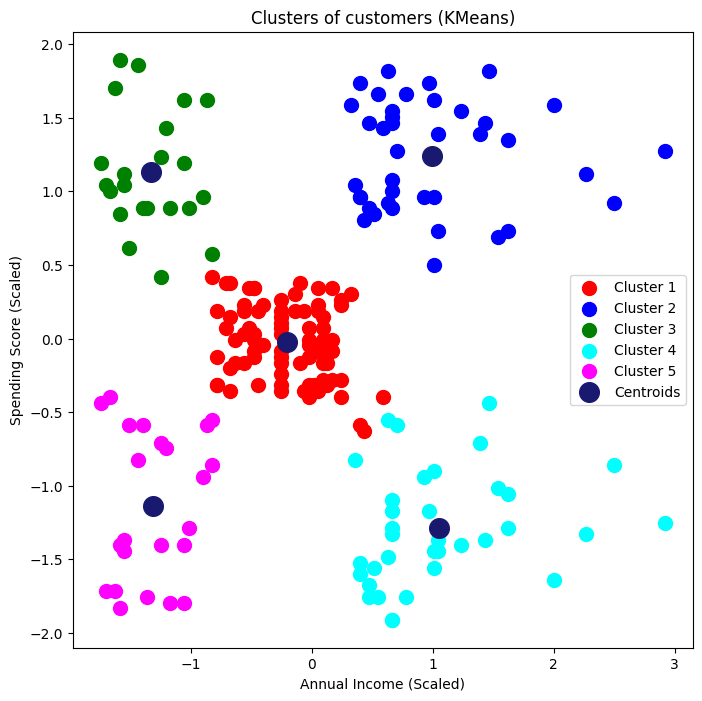

In [11]:
plot_clusters(
    X,
    y_kmeans,
    num_clusters=num_clusters,
    centroid_color="midnightblue",
    centroids=kmeans.cluster_centers_,
    x_label="Annual Income (Scaled)",
    y_label="Spending Score (Scaled)",
    title="Clusters of customers (KMeans)",
    colors=["red", "blue", "green", "cyan", "magenta"],
)

In [12]:
from IPython.display import display

dataset["cluster"] = y_kmeans
dataset
cluster_summary = dataset.groupby("cluster").mean(numeric_only=True)
display(cluster_summary)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


<Axes: xlabel='cluster', ylabel='Annual Income (k$)'>

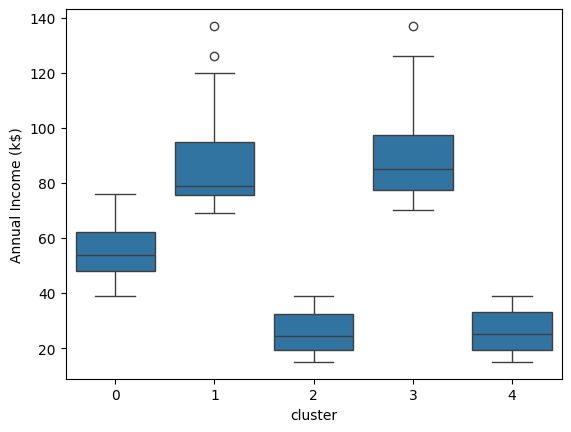

In [ ]:
import seaborn as sns

sns.boxplot(x="cluster", y="Annual Income (k$)", data=dataset)

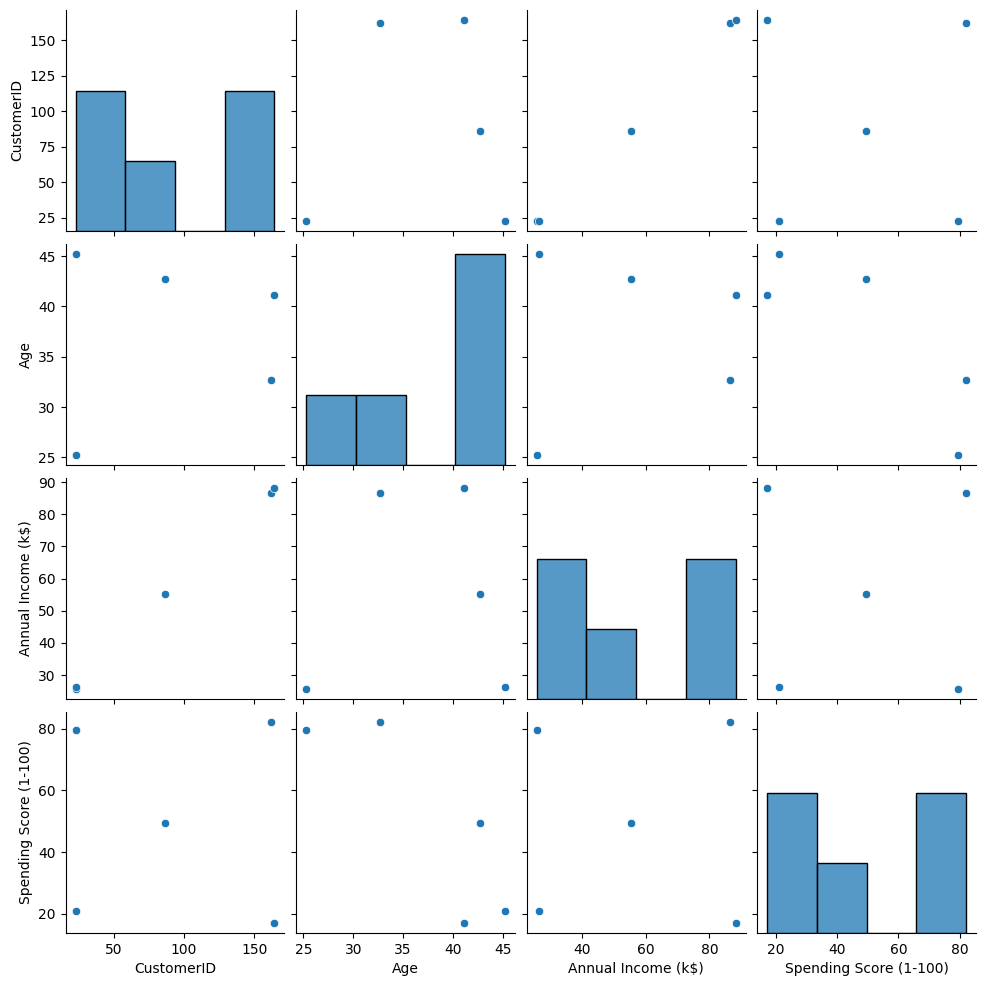

In [14]:
sns.pairplot(cluster_summary)

In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X, y_kmeans)
print(f"Silhouette Score: {silhouette:.2f}")

Silhouette Score: 0.55


## Part Two: Hierarchical Clustering


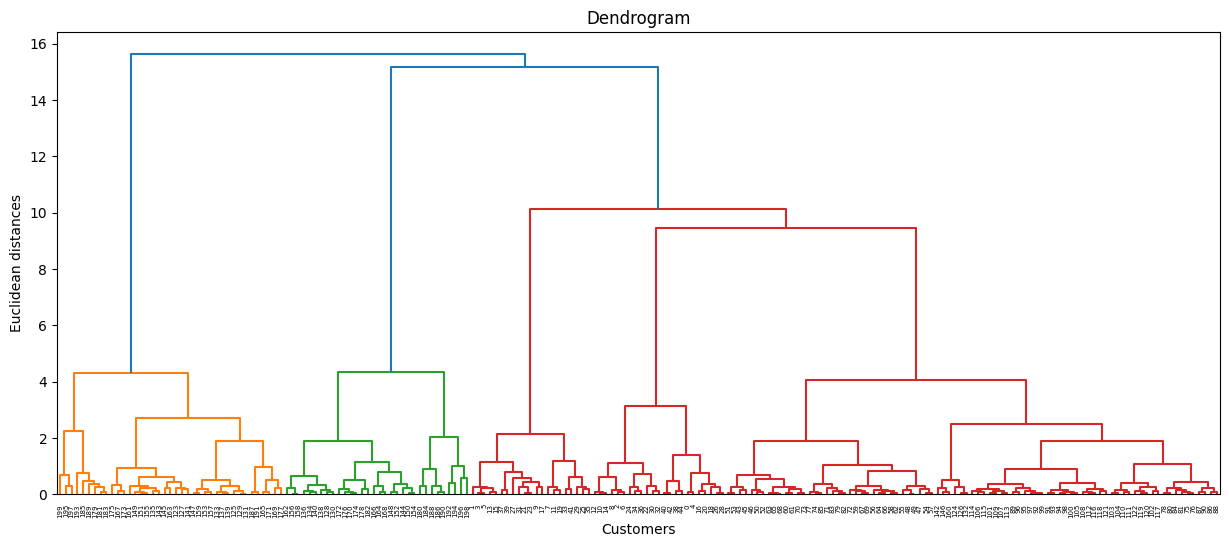

In [16]:
plt.figure(figsize=(15, 6))
Z = sch.linkage(X, method="ward")
dendrogram = sch.dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean distances")
plt.show()

In [17]:
num_clusters = 5
agglom = AgglomerativeClustering(
    n_clusters=num_clusters, metric="euclidean", linkage="ward"
)
y_agglom = agglom.fit_predict(X)
# y_agglom.shape, y_agglom, agglom.__dict__

y_values (200,)
X (200, 2)


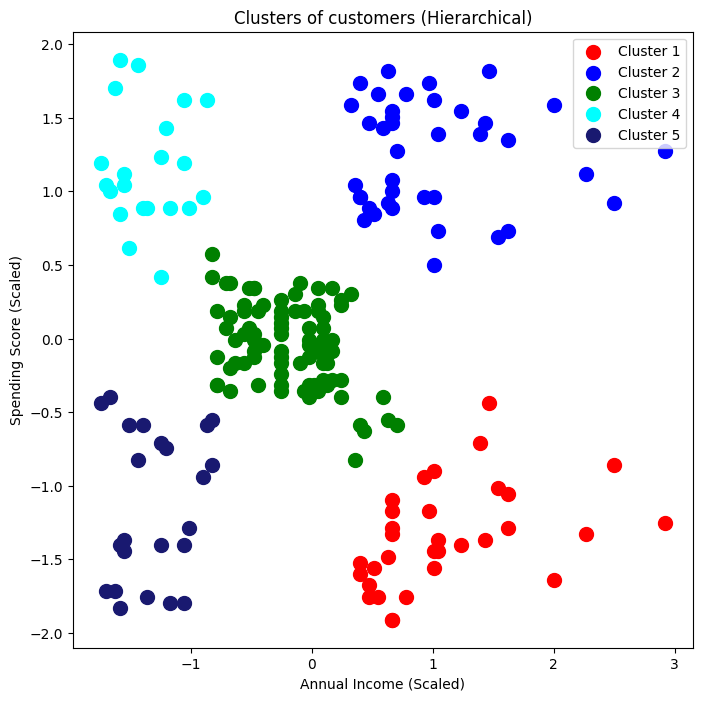

In [18]:
plot_clusters(
    X,
    y_agglom,
    num_clusters=num_clusters,
    colors=["red", "blue", "green", "cyan", "midnightblue"],
    title="Clusters of customers (Hierarchical)",
    x_label="Annual Income (Scaled)",
    y_label="Spending Score (Scaled)",
)

## Part Three: DBSCAN


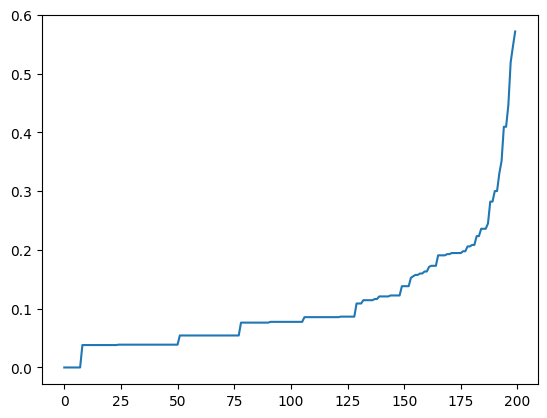

In [ ]:
neighbours = NearestNeighbors(n_neighbors=2)
distances, _ = neighbours.fit(X).kneighbors(X)

distances = distances[:, -1]
distances = np.sort(distances, axis=0)
plt.plot(distances)

In [20]:
dbscan = DBSCAN(eps=0.25, min_samples=5)
y_dbscan = dbscan.fit_predict(X)

y_values (200,)
X (200, 2)


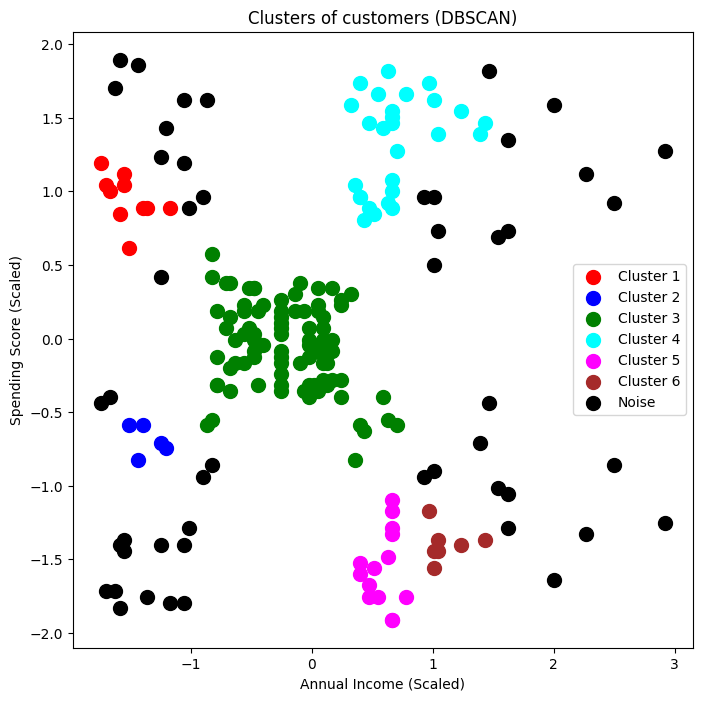

In [21]:
plot_clusters(
    X,
    y_dbscan,
    num_clusters=6,
    colors=["red", "blue", "green", "cyan", "magenta", "brown"],
    title="Clusters of customers (DBSCAN)",
    x_label="Annual Income (Scaled)",
    y_label="Spending Score (Scaled)",
    noise_color="black",
    plot_noise=True,
)

## Part Four: Clustering Data with Higher Dimensionality


In [22]:
financials = pd.read_csv("data/costpercompany.csv")
financials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company       29 non-null     object 
 1   surcharges    29 non-null     float64
 2   RoR           29 non-null     float64
 3   dailycost     29 non-null     int64  
 4   costwithload  29 non-null     float64
 5   costofDemand  29 non-null     float64
 6   Sales         29 non-null     int64  
 7   WearandTear   29 non-null     float64
 8   Fcost         29 non-null     float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.2+ KB


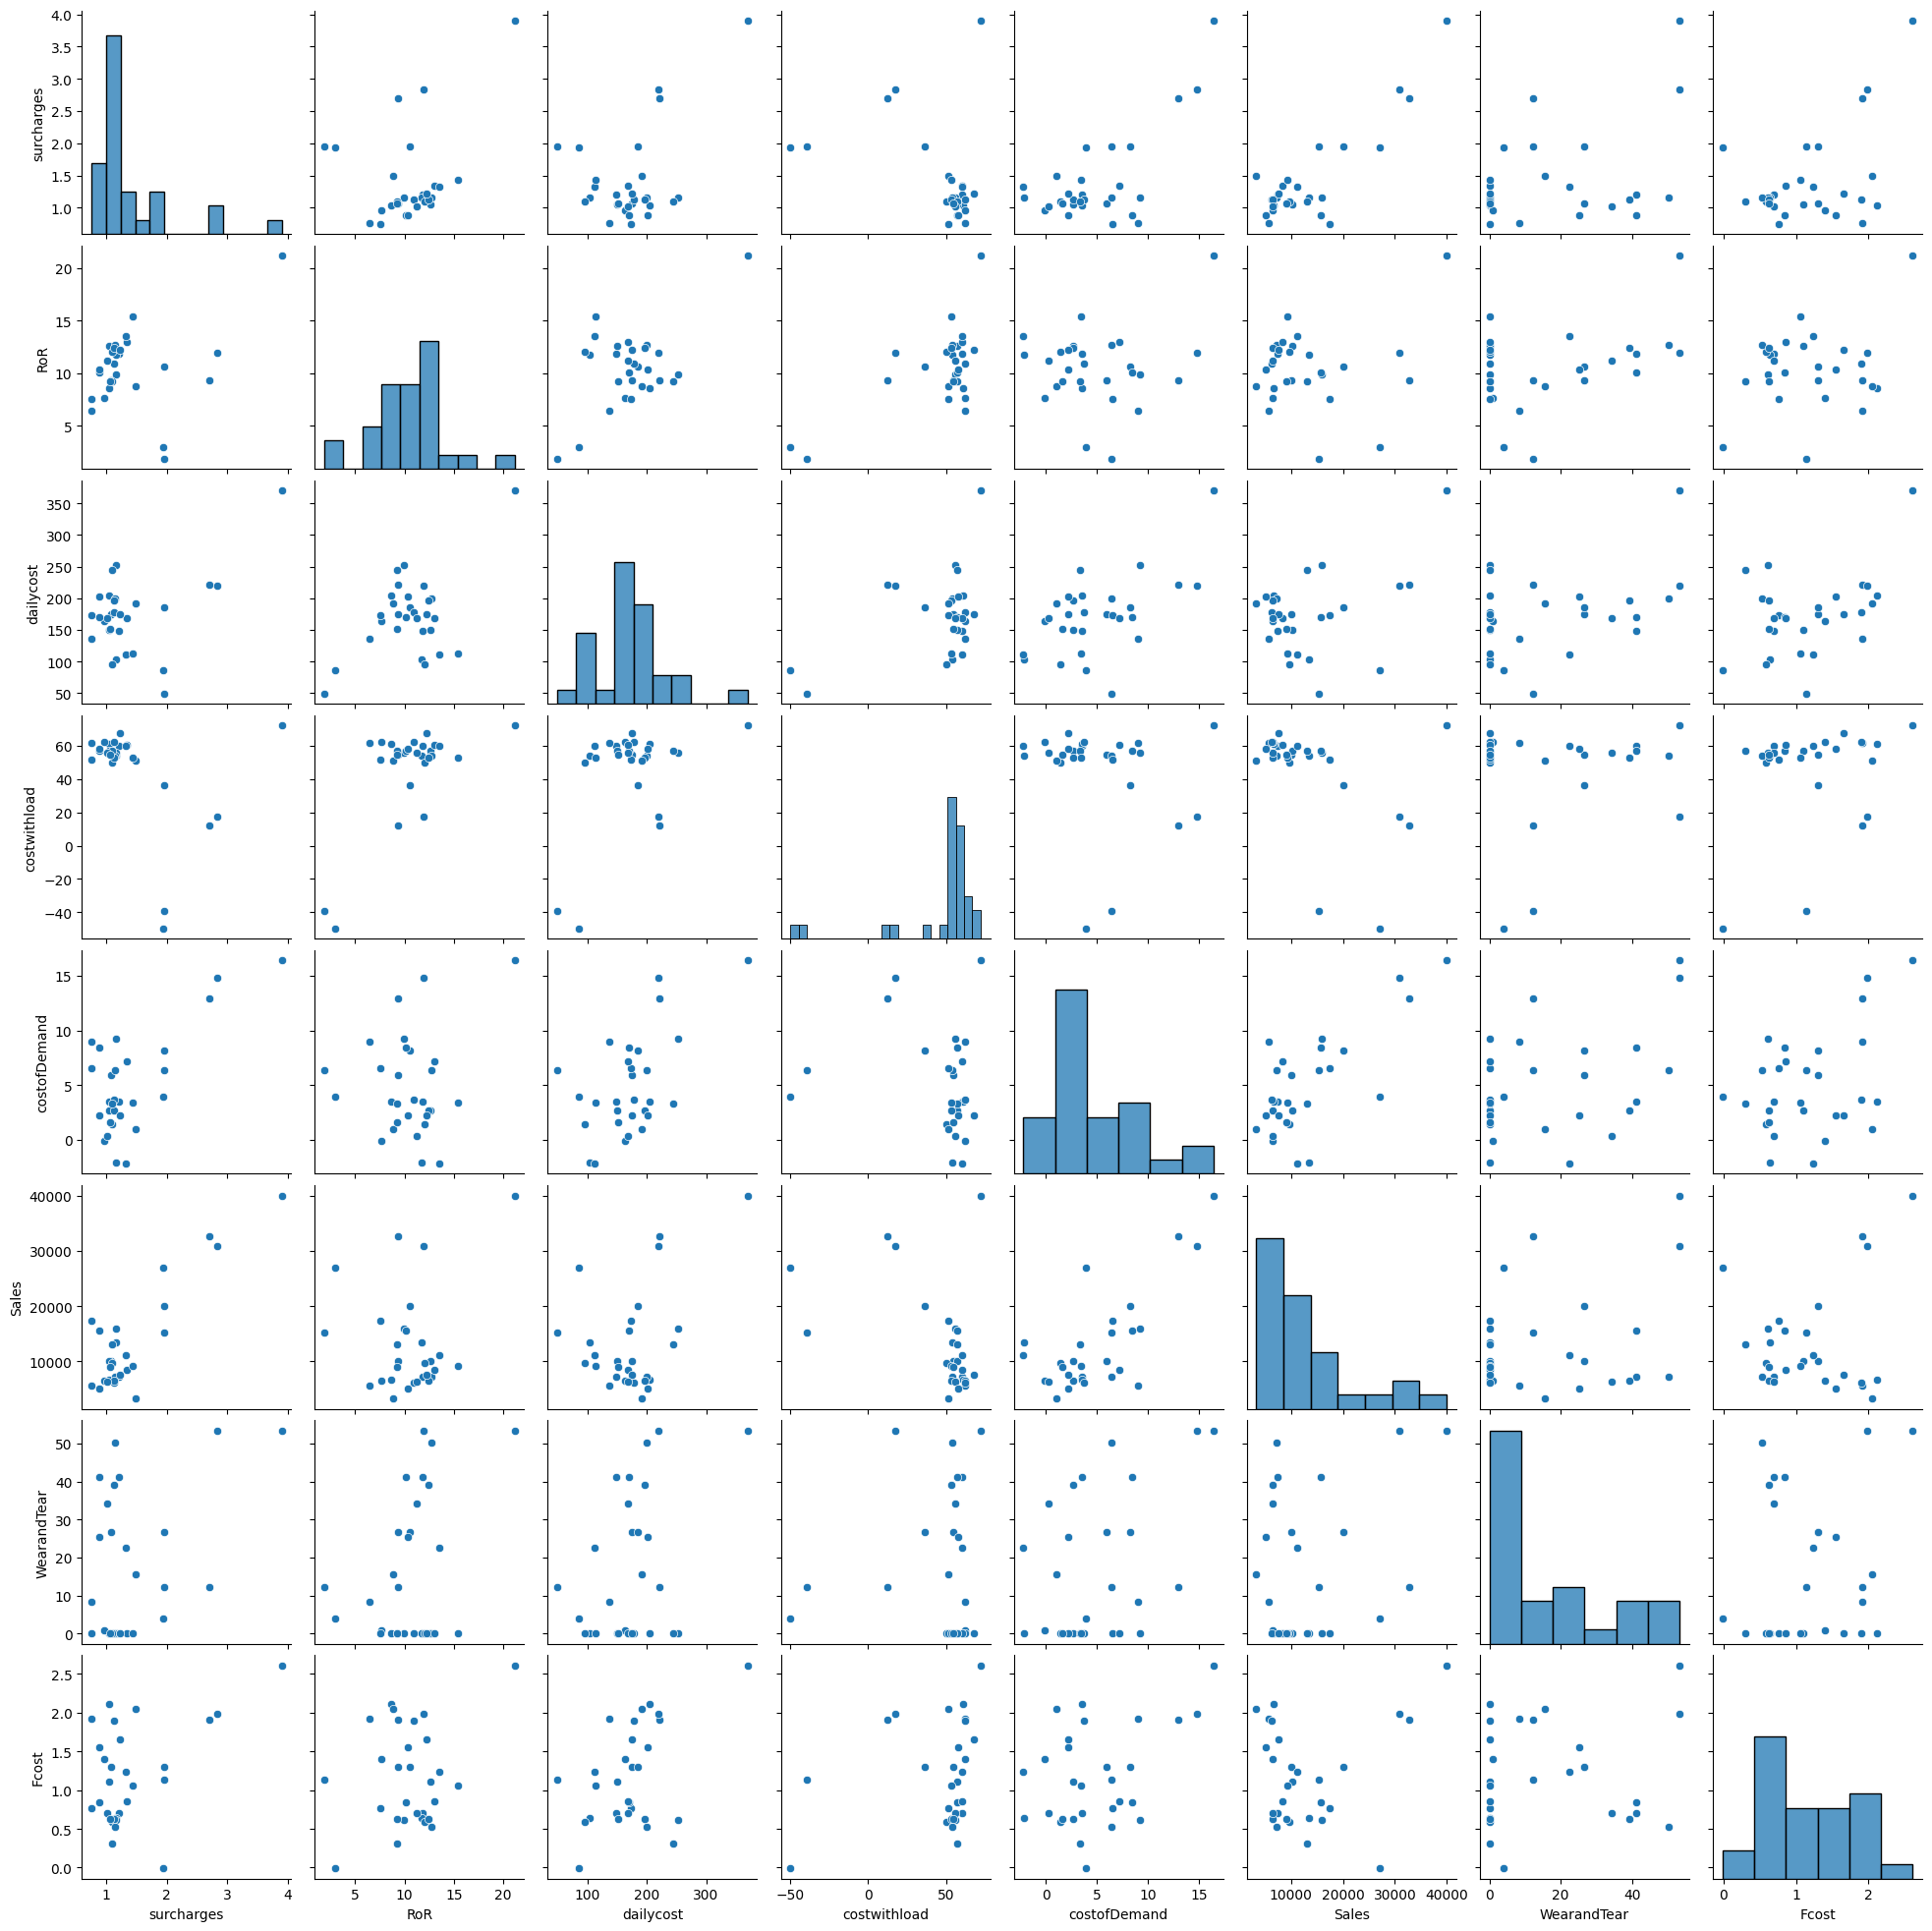

In [23]:
X = financials.iloc[:, 1:9]
sns.pairplot(X)

In [24]:
sc_X = StandardScaler()
X = sc_X.fit_transform(X)

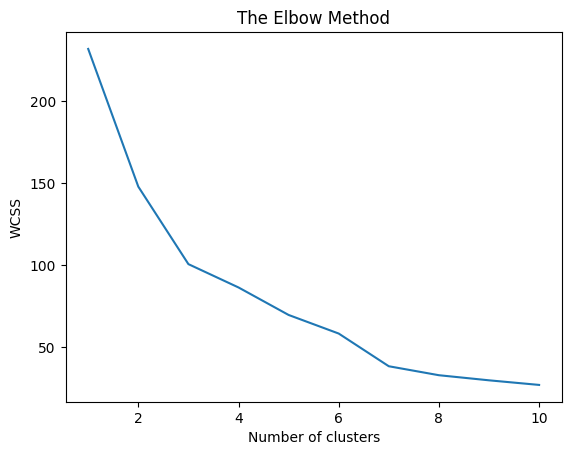

In [25]:
plot_k_means_elbow(X)

In [26]:
high_dim_n_clusters = 4

kmeans_high_dim = KMeans(
    n_init="auto", n_clusters=high_dim_n_clusters, init="k-means++", random_state=42
)
y_kmeans_high_dim = kmeans_high_dim.fit_predict(X)

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

pca.explained_variance_ratio_
X_reduced.shape

(29, 2)

y_values (29,)
X (29, 2)


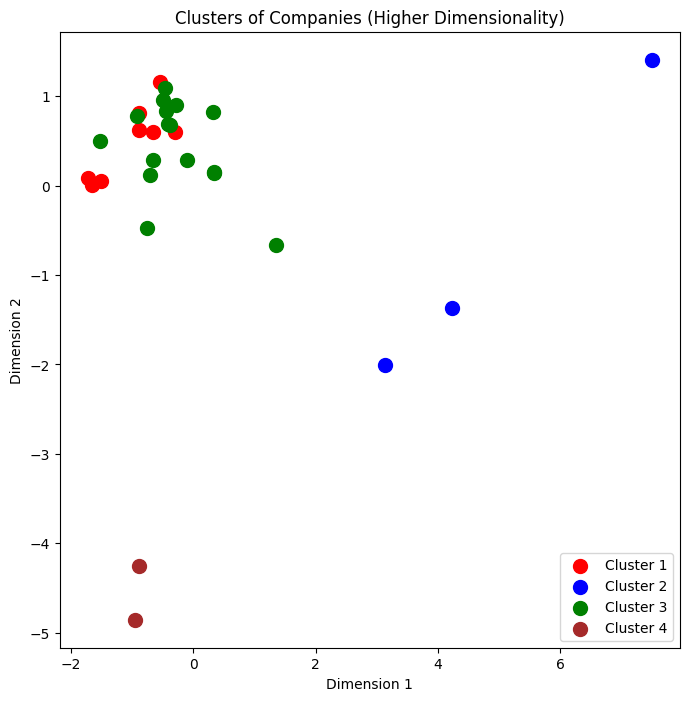

In [28]:
plot_clusters(
    X_reduced,
    y_kmeans_high_dim,
    num_clusters=high_dim_n_clusters,
    colors=["red", "blue", "green", "brown"],
    title="Clusters of Companies (Higher Dimensionality)",
    x_label="Dimension 1",
    y_label="Dimension 2",
)

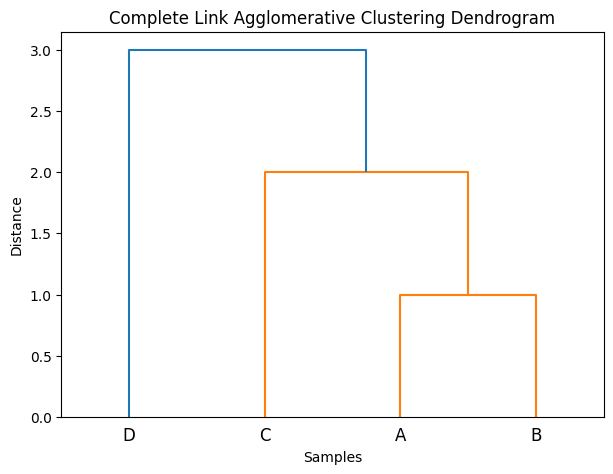

In [29]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np

# Distance matrix from Image 1 (A, B, C, D)
# We represent this as a condensed distance matrix for linkage()
# Distances: AB=1, AC=4, AD=5, BC=2, BD=6, CD=3
distances = np.array([1, 4, 5, 2, 6, 3])

# Perform hierarchical clustering using complete linkage
Z = linkage(distances, method="single")

# Plot dendrogram
plt.figure(figsize=(7, 5))
dendrogram(Z, labels=["A", "B", "C", "D"])
plt.title("Complete Link Agglomerative Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
# Generate simple 2D data with strong direction
np.random.seed(0)
data = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T
print(data.shape)

# Fit PCA
pca = PCA(n_components=2)
pca.fit(data)
data_pca = pca.transform(data)
explained = pca.explained_variance_ratio_

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Left: raw data with PCs
axes[0].scatter(data[:, 0], data[:, 1], alpha=0.5)
origin = np.mean(data, axis=0)
for length, vector in zip(pca.explained_variance_, pca.components_):
    print("component ", vector)
    print("length ", length)
    axes[0].arrow(
        origin[0],
        origin[1],
        vector[0] * 2 * np.sqrt(length),
        vector[1] * 2 * np.sqrt(length),
        color="red",
        width=0.02,
    )
axes[0].set_title("Original Data and PCs")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
# Right: projected data
axes[1].scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5)
axes[1].set_title("Data in PC Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

print("Explained variance ratios:", explained)